# Project Overview


Dataset: Diabetes 130-US Hospitals: Predicting Early Hospital Readmission

This project uses the Diabetes 130-US Hospitals for Years 1999–2008 dataset from the UCI Machine Learning Repository. The dataset contains hospital encounters for patients with diabetes across 130 U.S. hospitals and integrated delivery networks. I selected this dataset because hospital readmission represents an important health services outcome and the dataset provides a large, clinically rich collection of demographic, utilization, diagnostic, laboratory, and medication variables suitable for developing a supervised classification pipeline.
The proposed prediction problem is to identify hospital encounters associated with early readmission within 30 days of discharge.

Dataset suitability: The dataset contains 101,766 hospital encounters and 50 variables, substantially exceeding the project requirements of at least 300 observations and 10 predictor variables. The original readmission outcome contains three categories (<30, >30, and NO). For this project, a binary target will be defined to compare readmission within 30 days (<30) with no recorded readmission (NO), while encounters with readmission after 30 days (>30) will be excluded from the primary classification cohort.

Clore, J., Cios, K., DeShazo, J., & Strack, B. (2014). Diabetes 130-US Hospitals for Years 1999-2008 [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5230J.



# Data Import

Two files:
"diabetic_data.csv" & "IDS_mapping.csv"

In [26]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from google.colab import files

# Upload dataset files
print("Please upload diabetic_data.csv and IDS_mapping.csv")
uploaded = files.upload()

# Load the primary dataset and ID mapping file
df = pd.read_csv(io.BytesIO(uploaded["diabetic_data.csv"]))
id_mapping = pd.read_csv(io.BytesIO(uploaded["IDS_mapping.csv"]))

# Confirm successful upload
print("\nFiles successfully loaded.")
print(f"Primary dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"ID mapping file: {id_mapping.shape[0]:,} rows × {id_mapping.shape[1]} columns")

Dataset successfully loaded.
Rows: 101,766
Columns: 50


# Dataset Structure


In [27]:
display(df.head())

print(f"Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")

df.info()

display(
    pd.DataFrame({
        "Data_Type": df.dtypes,
        "Unique_Values": df.nunique()
    })
)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Dataset dimensions: 101,766 rows × 50 columns
Unique patients: 71,518
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  i

,Data_Type,Unique_Values
encounter_id,int64,101766
patient_nbr,int64,71518
race,object,6
gender,object,3
age,object,10
weight,object,10
admission_type_id,int64,8
discharge_disposition_id,int64,26
admission_source_id,int64,17
time_in_hospital,int64,14


Predictor Variables: The dataset contains a mixture of demographic, clinical, healthcare-utilization, diagnostic, laboratory, and treatment variables. Demographic predictors include age, race, and gender. Index-hospitalization characteristics include admission type, admission source, discharge disposition, time in hospital, number of laboratory procedures, number of procedures, and number of medications. Prior healthcare utilization is represented by the numbers of outpatient, emergency, and inpatient encounters. Additional variables describe diagnoses, laboratory testing such as HbA1c and serum glucose, diabetes medications, insulin use, and changes in diabetes therapy.
Several variables that appear numeric, including admission_type_id, discharge_disposition_id, and admission_source_id, represent categorical codes rather than continuous quantities. Additionally, encounter_id and patient_nbr are identifiers and would not be appropriate predictors for model training.

# Binary Outcome

The original readmitted variable contains three categories: <30, >30, and NO. Because the proposed prediction problem focuses specifically on early readmission, <30 will define the positive outcome. Encounters with NO will define the negative outcome. Patients readmitted after 30 days (>30) represent a clinically distinct group and will be excluded from the primary binary classification analysis rather than automatically grouped with patients who were never readmitted.

In [28]:
#original variable
df["readmitted"].value_counts()

#visualize/calculate percentages
df["readmitted"].value_counts(normalize=True) * 100

#planned binary analytic cohort
analysis_df = df[df["readmitted"].isin(["<30", "NO"])].copy()

analysis_df["readmit_30d"] = (
    analysis_df["readmitted"] == "<30"
).astype(int)

analysis_df["readmit_30d"].value_counts()

,count
readmit_30d,
0,54864
1,11357


# Descriptive Statistics

In [29]:
df.describe().T

#categorical
df.describe(include="object").T

#clinical variables to examine - will touch up later
variables = [
    "age",
    "race",
    "gender",
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_emergency",
    "number_inpatient",
    "A1Cresult",
    "insulin"
]

for variable in variables:
    print(f"\n{variable}")
    print(df[variable].value_counts(dropna=False).head(15))


age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

race
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

time_in_hospital
time_in_hospital
3     17756
2     17224
1     14208
4     13924
5      9966
6      7539
7      5859
8      4391
9      3002
10     2342
11     1855
12     1448
13     1210
14     1042
Name: count, dtype: int64

num_lab_procedures
num_lab_procedures
1     3208
43    2804
44    2496
45    2376
38    2213
40    2201
46    2189
41    2117
42    2113
47    2106
39    2101
37    2079
49    2066
48    2058
36    1962
Name: count, dtype: int64

num_medications
num_me

Descriptive exploration demonstrates substantial heterogeneity in hospitalization characteristics and prior healthcare utilization. The dataset includes both continuous/count variables and high-dimensional categorical variables, indicating that different preprocessing approaches will be required before model development. Several variables also contain highly skewed distributions, particularly prior healthcare-utilization measures, with most encounters having few previous visits and relatively small groups having substantially greater utilization.

# Visualizations

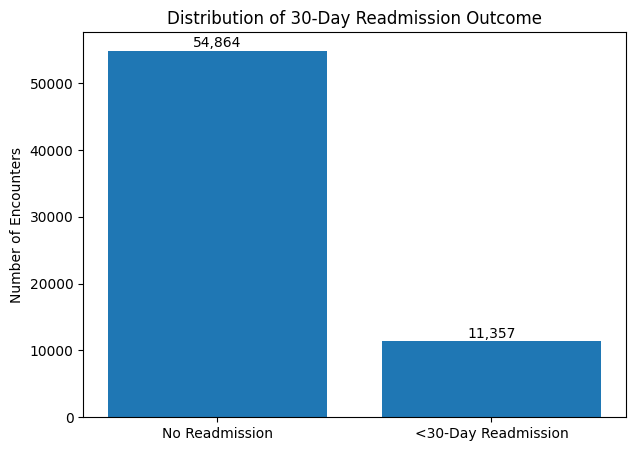

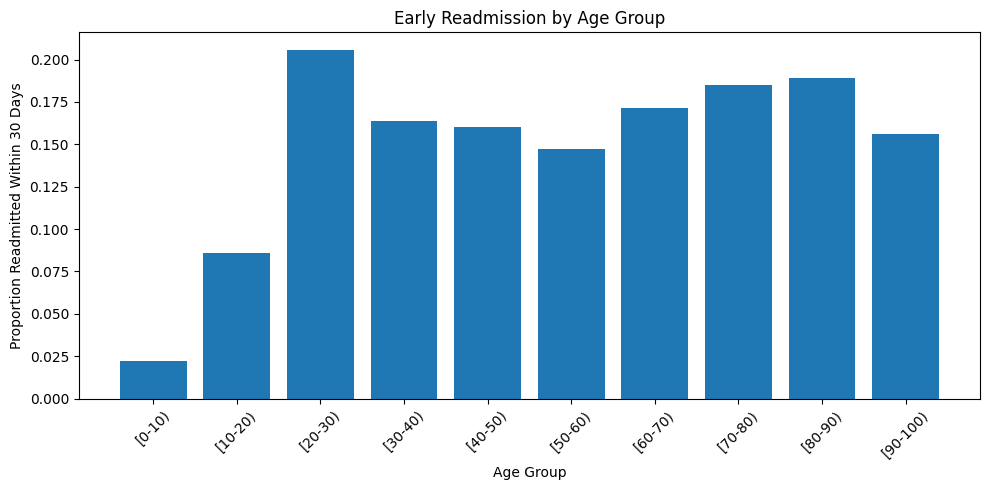

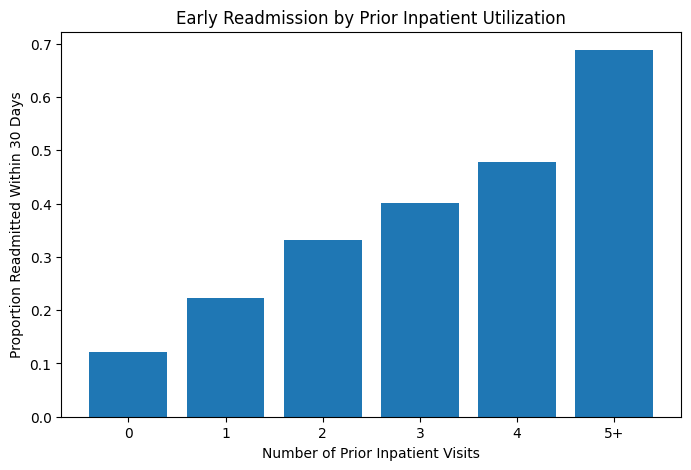

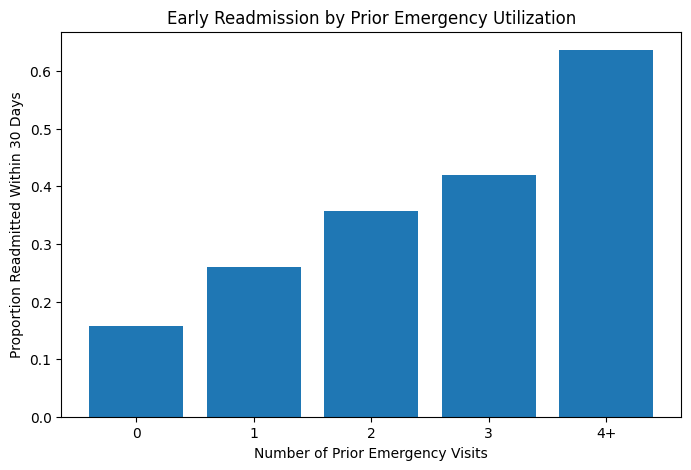

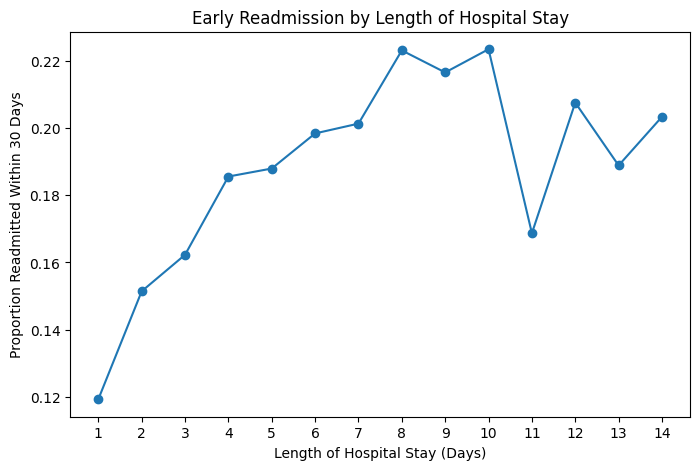

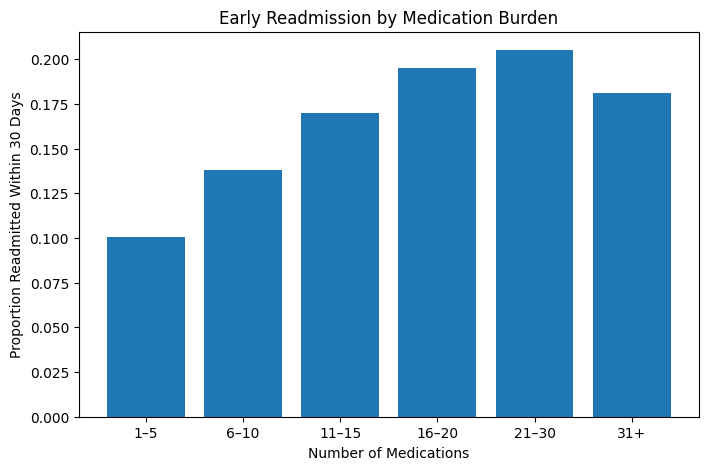

,medication_group,readmission_rate,n
0,1–5,0.100771,3761
1,6–10,0.138215,14217
2,11–15,0.170215,18835
3,16–20,0.195226,14117
4,21–30,0.205163,11698
5,31+,0.181186,3593


In [30]:
#Figure 1: Binary Outcome Distribution
outcome_summary = (
    analysis_df["readmit_30d"]
    .value_counts()
    .sort_index()
)

labels = ["No Readmission", "<30-Day Readmission"]

plt.figure(figsize=(7, 5))
plt.bar(labels, outcome_summary.values)

plt.ylabel("Number of Encounters")
plt.title("Distribution of 30-Day Readmission Outcome")

for i, count in enumerate(outcome_summary.values):
    plt.text(i, count + 500, f"{count:,}", ha="center")

plt.show()

#Figure 2: Early Readmission by Age Group
age_readmission = (
    analysis_df
    .groupby("age", observed=True)
    .agg(
        readmission_rate=("readmit_30d", "mean"),
        n=("readmit_30d", "size")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(
    age_readmission["age"],
    age_readmission["readmission_rate"]
)

plt.xlabel("Age Group")
plt.ylabel("Proportion Readmitted Within 30 Days")
plt.title("Early Readmission by Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

age_readmission

#Figure 3: Prior inpatient utilization vs early readmission
analysis_df["inpatient_group"] = analysis_df["number_inpatient"].clip(upper=5)

readmission_by_inpatient = (
    analysis_df
    .groupby("inpatient_group", observed=True)
    .agg(
        readmission_rate=("readmit_30d", "mean"),
        n=("readmit_30d", "size")
    )
    .reset_index()
)

readmission_by_inpatient["inpatient_group"] = (
    readmission_by_inpatient["inpatient_group"]
    .replace({5: "5+"})
)

plt.figure(figsize=(8, 5))
plt.bar(
    readmission_by_inpatient["inpatient_group"].astype(str),
    readmission_by_inpatient["readmission_rate"]
)

plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Proportion Readmitted Within 30 Days")
plt.title("Early Readmission by Prior Inpatient Utilization")
plt.show()

readmission_by_inpatient

#Figure 4: Prior Emergency Utilization
analysis_df["emergency_group"] = (
    analysis_df["number_emergency"].clip(upper=4)
)

emergency_readmission = (
    analysis_df
    .groupby("emergency_group", observed=True)
    .agg(
        readmission_rate=("readmit_30d", "mean"),
        n=("readmit_30d", "size")
    )
    .reset_index()
)

emergency_readmission["emergency_label"] = (
    emergency_readmission["emergency_group"]
    .replace({4: "4+"})
    .astype(str)
)

plt.figure(figsize=(8, 5))
plt.bar(
    emergency_readmission["emergency_label"],
    emergency_readmission["readmission_rate"]
)

plt.xlabel("Number of Prior Emergency Visits")
plt.ylabel("Proportion Readmitted Within 30 Days")
plt.title("Early Readmission by Prior Emergency Utilization")
plt.show()

emergency_readmission

#Figure 5: Length of Stay and Early Readmission
los_readmission = (
    analysis_df
    .groupby("time_in_hospital", observed=True)
    .agg(
        readmission_rate=("readmit_30d", "mean"),
        n=("readmit_30d", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    los_readmission["time_in_hospital"],
    los_readmission["readmission_rate"],
    marker="o"
)

plt.xlabel("Length of Hospital Stay (Days)")
plt.ylabel("Proportion Readmitted Within 30 Days")
plt.title("Early Readmission by Length of Hospital Stay")
plt.xticks(range(1, 15))
plt.show()

los_readmission

#Figure 6: Number of Medications
analysis_df["medication_group"] = pd.cut(
    analysis_df["num_medications"],
    bins=[0, 5, 10, 15, 20, 30, float("inf")],
    labels=["1–5", "6–10", "11–15", "16–20", "21–30", "31+"]
)

medication_readmission = (
    analysis_df
    .groupby("medication_group", observed=True)
    .agg(
        readmission_rate=("readmit_30d", "mean"),
        n=("readmit_30d", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    medication_readmission["medication_group"].astype(str),
    medication_readmission["readmission_rate"]
)

plt.xlabel("Number of Medications")
plt.ylabel("Proportion Readmitted Within 30 Days")
plt.title("Early Readmission by Medication Burden")
plt.show()

medication_readmission


Exploratory analyses identified several potential relationships with early readmission. Prior healthcare utilization showed the clearest pattern: early readmission increased from 12.1% among encounters with no prior inpatient visits to 68.8% among those with five or more. A similar gradient was observed for prior emergency utilization. Early readmission also generally increased with longer hospital stays and greater medication burden, although these relationships were not strictly monotonic. These findings are descriptive and unadjusted and should not be interpreted as causal relationships.

# Data Quality and Missingness

,Missing_Count,Missing_Percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


Unique patients: 71,518
Patients with one encounter: 54,745
Patients with multiple encounters: 16,773
Maximum encounters for one patient: 40


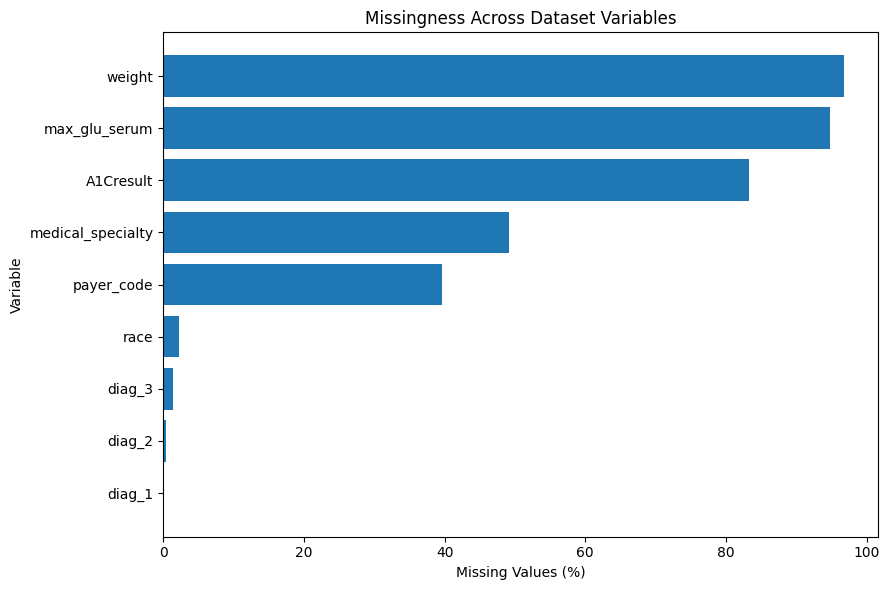

In [31]:
#Missing Values

# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

# Standardize "?" entries as missing values
df_clean = df_clean.replace("?", np.nan)

# Calculate missing counts and percentages
missing_counts = df_clean.isna().sum()
missing_percent = (missing_counts / len(df_clean)) * 100

# Create missingness summary table
missing_table = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
})

# Keep only variables containing missing values
missing_table = (
    missing_table[missing_table["Missing_Count"] > 0]
    .sort_values("Missing_Percent", ascending=False)
)

display(missing_table)

# Assess repeated patient encounters
encounters_per_patient = df.groupby("patient_nbr").size()

print(f"Unique patients: {df['patient_nbr'].nunique():,}")
print(f"Patients with one encounter: {(encounters_per_patient == 1).sum():,}")
print(f"Patients with multiple encounters: {(encounters_per_patient > 1).sum():,}")
print(f"Maximum encounters for one patient: {encounters_per_patient.max()}")

# Visualize missingness
plt.figure(figsize=(9, 6))
plt.barh(
    missing_table.index,
    missing_table["Missing_Percent"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Variable")
plt.title("Missingness Across Dataset Variables")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Data Quality Assessment and Anticipated Preprocessing

**Missing data:** Missingness is substantial for several variables and is represented using both "?" and values recognized by pandas as NaN. These representations will first be standardized. Variables with extremely high missingness, such as weight, may be excluded from model development, while variables with more moderate missingness will require an appropriate strategy such as imputation or creation of an explicit unknown category.

**Variable encoding:** Several integer-valued variables represent categorical codes rather than continuous measurements. These variables will be mapped using the accompanying ID file and treated as categorical features. Other categorical predictors will require encoding before use in machine-learning models.

**Identifiers and Repeated Encounters:** encounter_id and patient_nbr are identifiers and will not be used as predictors. Because the dataset contains 101,766 encounters but only 71,518 unique patients, some patients contribute multiple observations. This creates potential dependence between observations and the possibility of information leakage if encounters from the same patient appear in both training and testing datasets. A patient-level splitting strategy will therefore be considered during model development.

**High-dimensional categorical variables:** Diagnosis codes and medical specialty contain many possible categories and may require clinically meaningful grouping or encoding to avoid excessive dimensionality.
Class imbalance. Early readmission represents a minority of the proposed binary cohort. Model evaluation will therefore emphasize metrics that account for performance on the positive class rather than relying on accuracy alone.

**Outcome definition:** Encounters with readmission after 30 days (>30) will be excluded from the primary binary classification cohort because they represent a clinically distinct outcome from both early readmission and no recorded readmission.

9. Project Planning

**Proposed Prediction Problem:**
The proposed final project will develop a supervised classification pipeline to predict early hospital readmission among encounters involving patients with diabetes. The primary question is: Can demographic, clinical, healthcare-utilization, laboratory, and treatment characteristics available during the index hospitalization predict readmission within 30 days of discharge?

**Target Variable:**
The binary target variable will be readmit_30d, defined as:
- 1: readmission within 30 days (<30)
- 0: no recorded readmission (NO)
Encounters with readmission after 30 days (>30) will be excluded from the primary analysis.

**Candidate Evaluation Metric:** F1 score will be considered as the primary model-evaluation metric. Early readmission accounts for approximately 17% of encounters in the proposed binary cohort, creating class imbalance. Accuracy could therefore appear high even for a model that performs poorly at identifying early readmissions. F1 score incorporates both precision and recall and provides a more informative assessment of performance on the minority outcome. Accuracy, precision, recall, and ROC-AUC will also be evaluated as secondary performance measures in the final project.